In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\hp\Downloads\messy_HR_data.csv")
df 

,Name,Age,Salary,Gender,Department,Position,Joining Date,Performance Score,Email,Phone Number
0,grace,25,50000,Male,HR,Manager,"April 5, 2018",D,email@example.com,NaN
1,david,NaN,65000,Female,Finance,Director,2020/02/20,F,user@domain.com,123-456-7890
2,hannah,35,SIXTY THOUSAND,Female,Sales,Director,01/15/2020,C,email@example.com,098-765-4321
3,eve,NaN,50000,Female,IT,Manager,"April 5, 2018",A,name@company.org,
4,grace,NaN,NAN,Female,Finance,Manager,01/15/2020,F,name@company.org,098-765-4321
...,...,...,...,...,...,...,...,...,...,...
995,jack,50,65000,Female,HR,Manager,2020/02/20,F,NaN,098-765-4321
996,jack,thirty,50000,Male,Finance,Analyst,"April 5, 2018",C,NaN,555-555-5555
997,hannah,thirty,70000,Male,IT,Assistant,01/15/2020,D,user@domain.com,NaN
998,bob,25,65000,Other,Marketing,Manager,"April 5, 2018",D,email@example.com,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Name               1000 non-null   object
 1   Age                841 non-null    object
 2   Salary             1000 non-null   object
 3   Gender             1000 non-null   object
 4   Department         1000 non-null   object
 5   Position           1000 non-null   object
 6   Joining Date       1000 non-null   object
 7   Performance Score  1000 non-null   object
 8   Email              610 non-null    object
 9   Phone Number       815 non-null    object
dtypes: object(10)
memory usage: 78.3+ KB


In [4]:
for col in df.columns:
    print(col, df[col].unique())

Name [' grace ' ' david ' ' hannah ' ' eve ' ' jack ' ' charlie ' ' frank '
 ' bob ' ' alice ' ' ivy ']
Age ['25' nan '35' '40' 'thirty' '50']
Salary ['50000' '65000' 'SIXTY THOUSAND' ' NAN ' '70000' '55000']
Gender ['Male' 'Female' 'Other']
Department ['HR' 'Finance' 'Sales' 'IT' 'Marketing']
Position ['Manager' 'Director' 'Clerk' 'Assistant' 'Analyst']
Joining Date ['April 5, 2018' '2020/02/20' '01/15/2020' '03-25-2019' '2019.12.01']
Performance Score ['D' 'F' 'C' 'A' 'B']
Email ['email@example.com' 'user@domain.com' 'name@company.org' nan]
Phone Number [nan '123-456-7890' '098-765-4321' ' ' '555-555-5555']


In [5]:
df.isnull().sum()

Name                   0
Age                  159
Salary                 0
Gender                 0
Department             0
Position               0
Joining Date           0
Performance Score      0
Email                390
Phone Number         185
dtype: int64

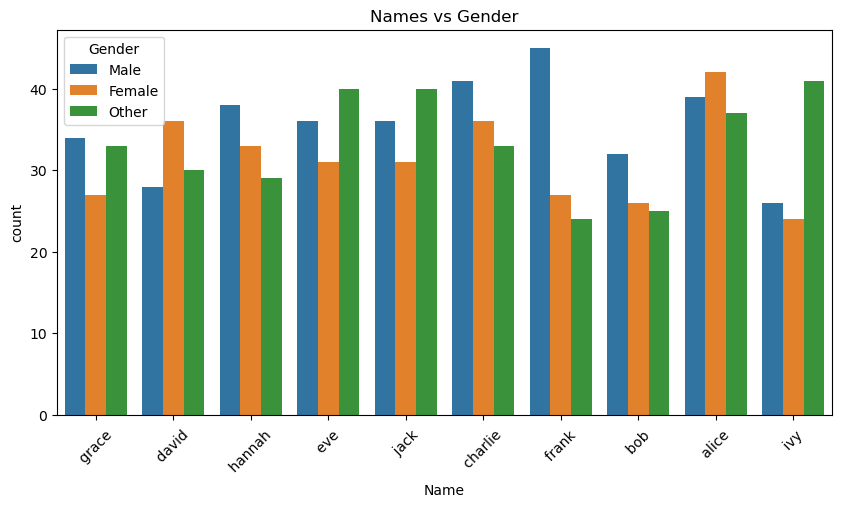

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(x="Name", hue="Gender", data=df)
plt.title("Names vs Gender")
plt.xticks(rotation=45)
plt.show()

In [7]:
gender_map = {
    "grace": "Female",
    "david": "Male",
    "hannah": "Female",
    "eve": "Female",
    "jack": "Male",
    "charlie": "Male",
    "frank": "Male",
    "bob": "Male",
    "alice": "Female",
    "ivy": "Female"
}

df["Gender"] = df["Name"].str.strip().str.lower().map(gender_map)

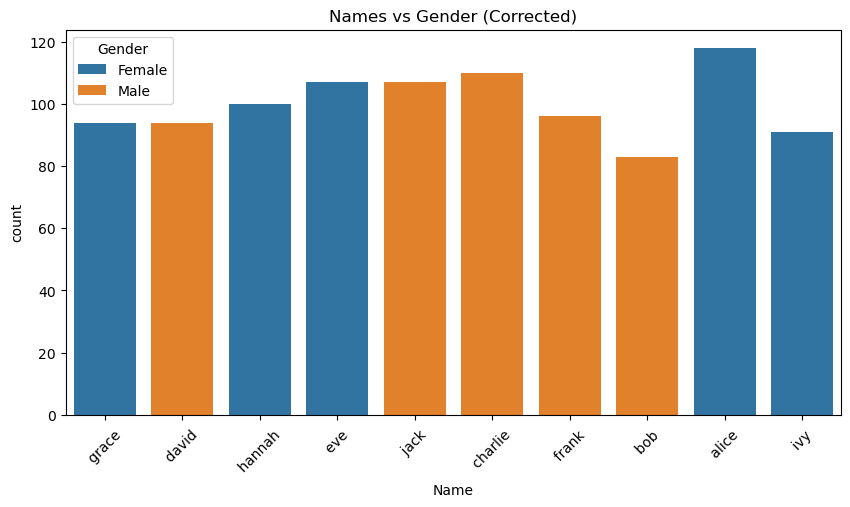

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(x="Name", hue="Gender", data=df)
plt.title("Names vs Gender (Corrected)")
plt.xticks(rotation=45)
plt.show()

In [9]:
df["Age"] = df["Age"].replace("thirty", 30)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

<Axes: title={'center': 'Age Distribution (Before Filling)'}, ylabel='Frequency'>

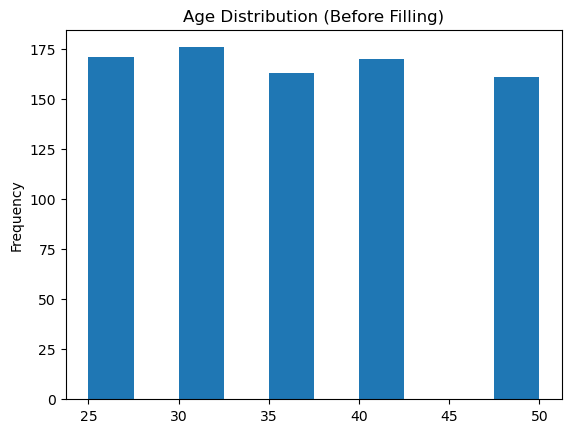

In [10]:
df["Age"].plot(kind="hist", title="Age Distribution (Before Filling)")

In [11]:
ages = df["Age"].dropna()
df["Age"] = df["Age"].apply(lambda x: np.random.choice(ages) if pd.isna(x) else x)

<Axes: title={'center': 'Age Distribution (After Filling)'}, ylabel='Frequency'>

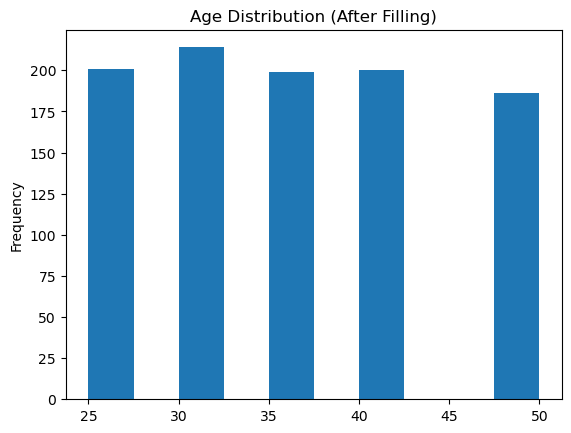

In [12]:
df["Age"].plot(kind="hist", title="Age Distribution (After Filling)")

In [13]:
df["Salary"] = df["Salary"].replace("SIXTY THOUSAND", 60000)
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")

In [14]:
df["Joining Date"] = df["Joining Date"].str.replace("April", "04")
df["Joining Date"] = df["Joining Date"].str.replace(r"[\/\.]", "-", regex=True)
df["Joining Date"] = df["Joining Date"].str.replace(",", "").str.strip()

def fix_format(x):
    parts = x.split("-") 
    if len(parts) == 3 and len(parts[0]) == 4:  
        return f"{parts[1].zfill(2)}-{parts[2].zfill(2)}-{parts[0]}"
    elif len(parts) == 3 and len(parts[2]) == 4:  
        return f"{parts[0].zfill(2)}-{parts[1].zfill(2)}-{parts[2]}"
    else:
        return x

df["Joining Date"] = df["Joining Date"].apply(fix_format)


In [15]:
df["Joining Date"] = df["Joining Date"].apply(
    lambda x: f"{x.split()[0]}-{x.split()[1].zfill(2)}-{x.split()[2]}" 
              if isinstance(x, str) and " " in x else x
)

In [16]:
df["Joining Date"] = df["Joining Date"].apply(
    lambda x: f"{x.split('-')[1].zfill(2)}-{x.split('-')[0].zfill(2)}-{x.split('-')[2]}" 
              if isinstance(x, str) and "-" in x else x
)

In [17]:
df["Joining Date"] = pd.to_datetime(df["Joining Date"], errors="coerce", dayfirst=True)

In [18]:
df.isnull().sum()

Name                   0
Age                    0
Salary               167
Gender                 0
Department             0
Position               0
Joining Date           0
Performance Score      0
Email                390
Phone Number         185
dtype: int64

In [19]:
for col in df.columns:
    print(col, df[col].unique())

Name [' grace ' ' david ' ' hannah ' ' eve ' ' jack ' ' charlie ' ' frank '
 ' bob ' ' alice ' ' ivy ']
Age [25. 35. 50. 30. 40.]
Salary [50000. 65000. 60000.    nan 70000. 55000.]
Gender ['Female' 'Male']
Department ['HR' 'Finance' 'Sales' 'IT' 'Marketing']
Position ['Manager' 'Director' 'Clerk' 'Assistant' 'Analyst']
Joining Date <DatetimeArray>
['2018-04-05 00:00:00', '2020-02-20 00:00:00', '2020-01-15 00:00:00',
 '2019-03-25 00:00:00', '2019-12-01 00:00:00']
Length: 5, dtype: datetime64[ns]
Performance Score ['D' 'F' 'C' 'A' 'B']
Email ['email@example.com' 'user@domain.com' 'name@company.org' nan]
Phone Number [nan '123-456-7890' '098-765-4321' ' ' '555-555-5555']


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Name               1000 non-null   object        
 1   Age                1000 non-null   float64       
 2   Salary             833 non-null    float64       
 3   Gender             1000 non-null   object        
 4   Department         1000 non-null   object        
 5   Position           1000 non-null   object        
 6   Joining Date       1000 non-null   datetime64[ns]
 7   Performance Score  1000 non-null   object        
 8   Email              610 non-null    object        
 9   Phone Number       815 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 78.3+ KB


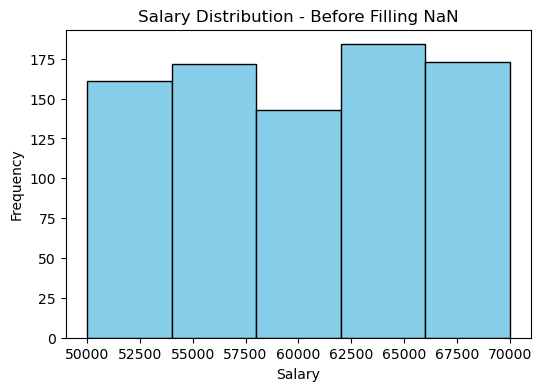

In [21]:
plt.figure(figsize=(6,4))
df["Salary"].plot(kind="hist", bins=5, color="skyblue", edgecolor="black")
plt.title("Salary Distribution - Before Filling NaN")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

In [22]:
df["Salary"] = df["Salary"].ffill()
df["Salary"] = df["Salary"].bfill()

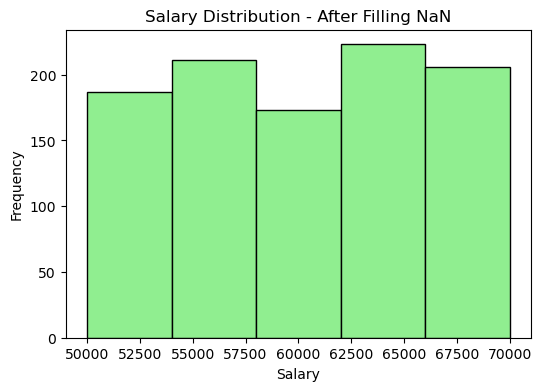

In [23]:
plt.figure(figsize=(6,4))
df["Salary"].plot(kind="hist", bins=5, color="lightgreen", edgecolor="black")
plt.title("Salary Distribution - After Filling NaN")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

In [24]:
df["Phone Number"] = df["Phone Number"].replace(" ", np.nan)

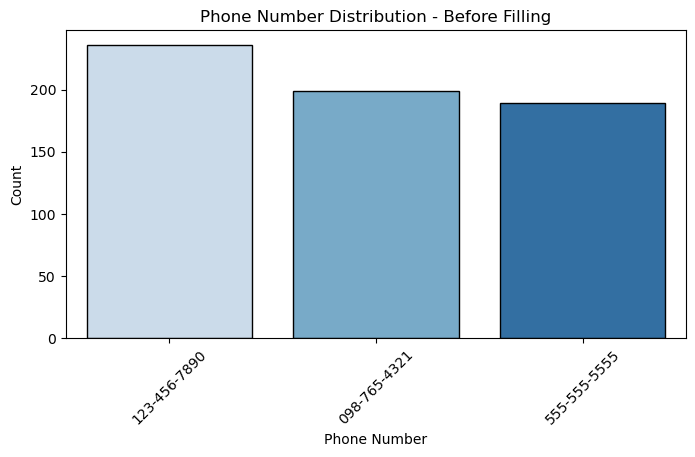

In [25]:
plt.figure(figsize=(8,4))

sns.countplot(
    x=df["Phone Number"], 
    hue=df["Phone Number"], 
    palette="Blues", 
    legend=False, 
    edgecolor="black"
)

plt.title("Phone Number Distribution - Before Filling")
plt.xlabel("Phone Number")
plt.ylabel("Count")
plt.xticks(rotation=45)  
plt.show()

In [26]:
df["Phone Number"] = df["Phone Number"].ffill().bfill()

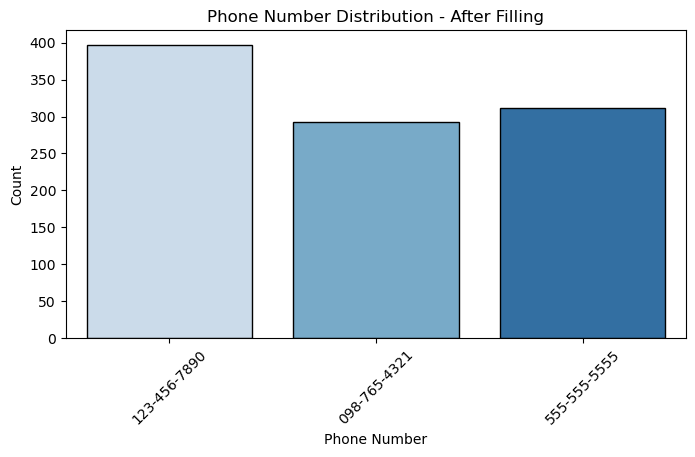

In [27]:
plt.figure(figsize=(8,4))

sns.countplot(
    x=df["Phone Number"], 
    hue=df["Phone Number"], 
    palette="Blues", 
    legend=False, 
    edgecolor="black"
)
plt.title("Phone Number Distribution - After Filling")
plt.xlabel("Phone Number")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

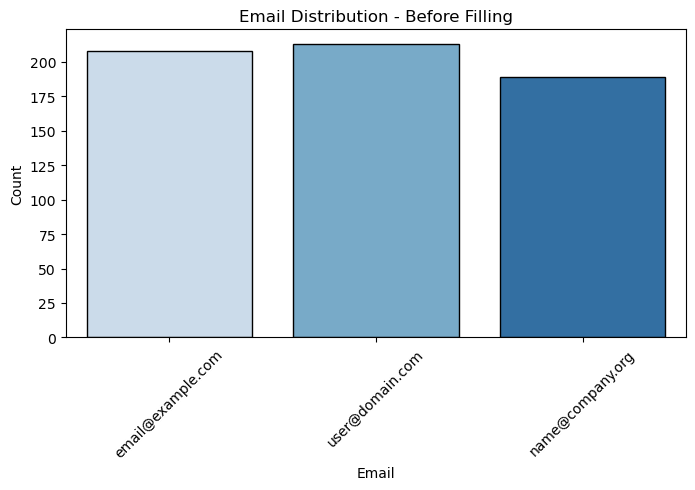

In [28]:
plt.figure(figsize=(8,4))

sns.countplot(
    x=df["Email"], 
    hue=df["Email"], 
    palette="Blues", 
    legend=False, 
    edgecolor="black"
)

plt.title("Email Distribution - Before Filling")
plt.xlabel("Email")
plt.ylabel("Count")
plt.xticks(rotation=45) 
plt.show()

In [29]:
df["Email"] = df["Email"].ffill().bfill()

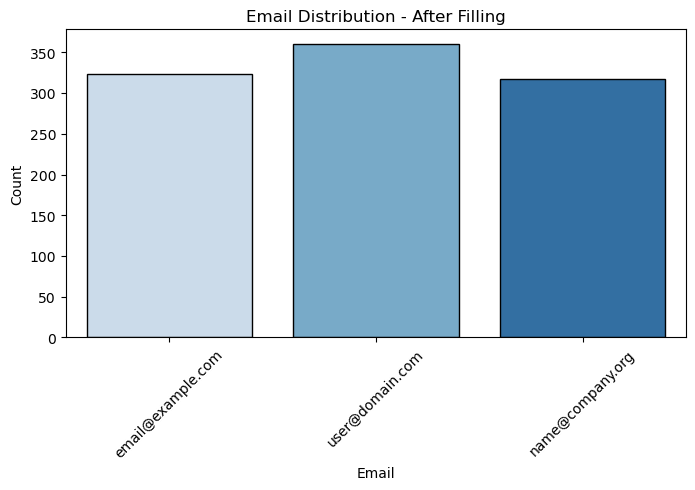

In [30]:
plt.figure(figsize=(8,4))

sns.countplot(
    x=df["Email"], 
    hue=df["Email"], 
    palette="Blues", 
    legend=False, 
    edgecolor="black"
)

plt.title("Email Distribution - After Filling")
plt.xlabel("Email")
plt.ylabel("Count")
plt.xticks(rotation=45) 
plt.show()

In [31]:
df.isnull().sum()

Name                 0
Age                  0
Salary               0
Gender               0
Department           0
Position             0
Joining Date         0
Performance Score    0
Email                0
Phone Number         0
dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Name               1000 non-null   object        
 1   Age                1000 non-null   float64       
 2   Salary             1000 non-null   float64       
 3   Gender             1000 non-null   object        
 4   Department         1000 non-null   object        
 5   Position           1000 non-null   object        
 6   Joining Date       1000 non-null   datetime64[ns]
 7   Performance Score  1000 non-null   object        
 8   Email              1000 non-null   object        
 9   Phone Number       1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 78.3+ KB


In [33]:
df.duplicated().sum()

np.int64(1)

## Departmental Performance Distribution

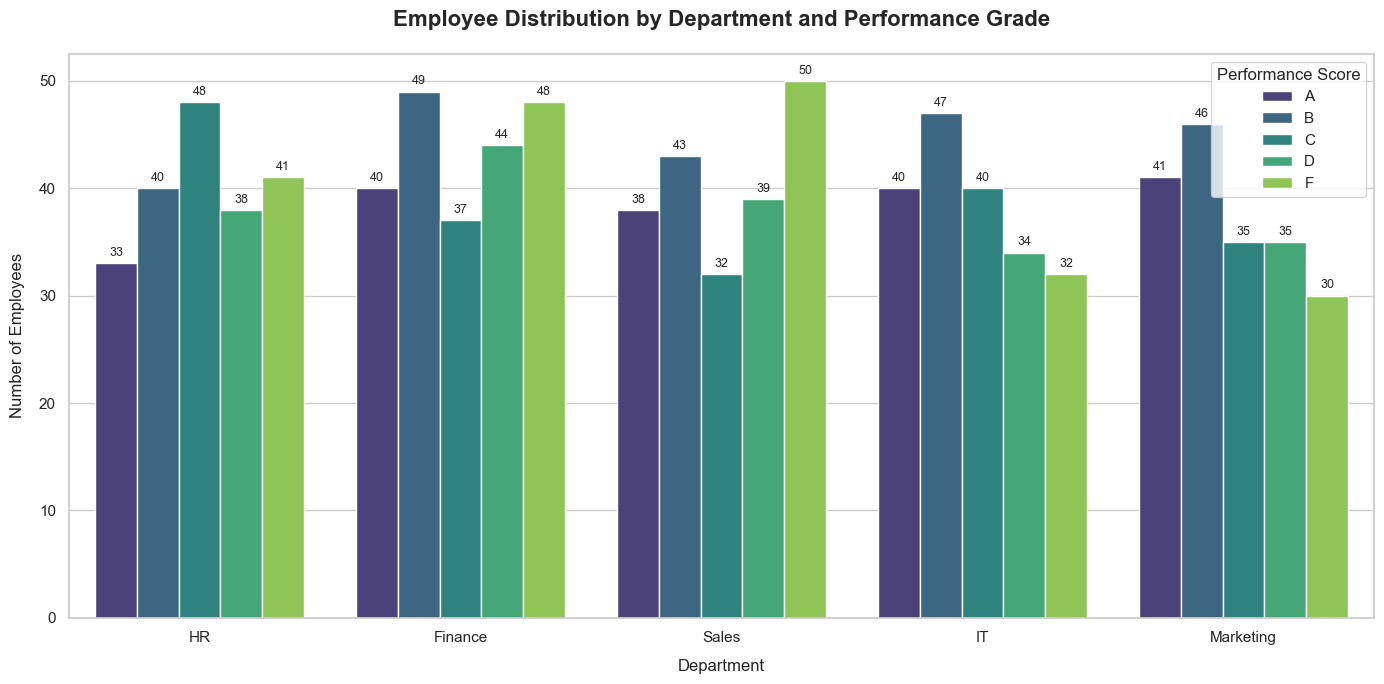

In [34]:
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
ax = sns.countplot(
    x="Department", 
    hue="Performance Score", 
    data=df, 
    hue_order=['A', 'B', 'C', 'D', 'F'], 
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
    
plt.title("Employee Distribution by Department and Performance Grade", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Department", fontsize=12, labelpad=10)
plt.ylabel("Number of Employees", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

## Average Salary Analysis

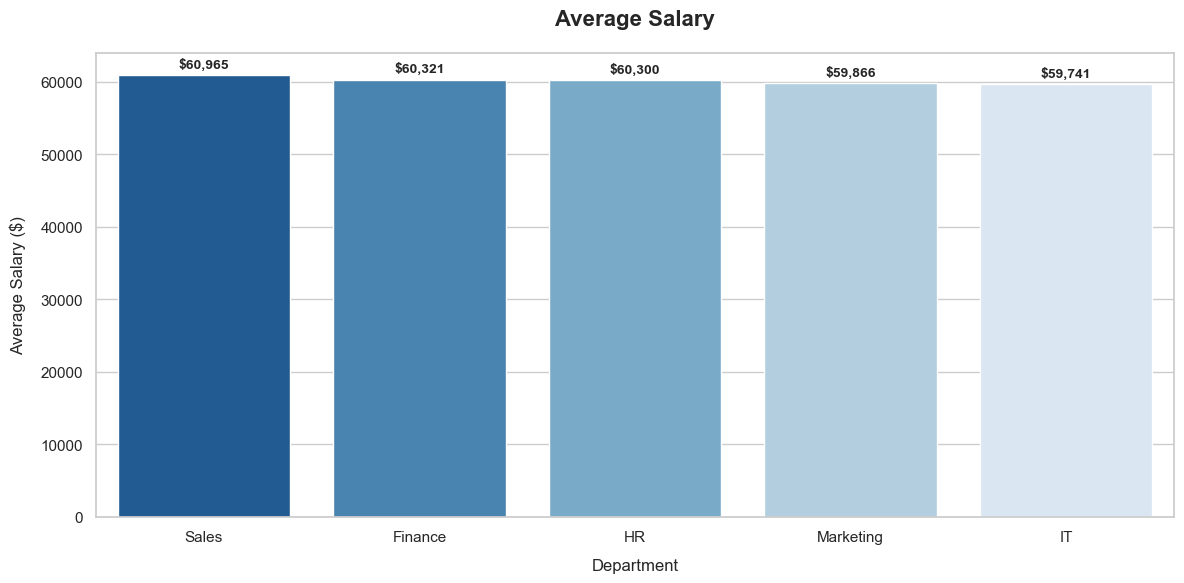

In [35]:
salary_df = df.groupby("Department")["Salary"].mean().reset_index()
salary_df = salary_df.sort_values(by="Salary", ascending=False)
plt.figure(figsize=(12, 6))

sns.set_theme(style="whitegrid")
ax = sns.barplot(
    x="Department", 
    y="Salary", 
    data=salary_df, 
    hue="Department",     
    legend=False,         
    palette="Blues_r" 
)

for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', padding=3, fontsize=10, fontweight="bold")
    
plt.title("Average Salary", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Department", fontsize=12, labelpad=10)
plt.ylabel("Average Salary ($)", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

## Workforce Composition Analysis

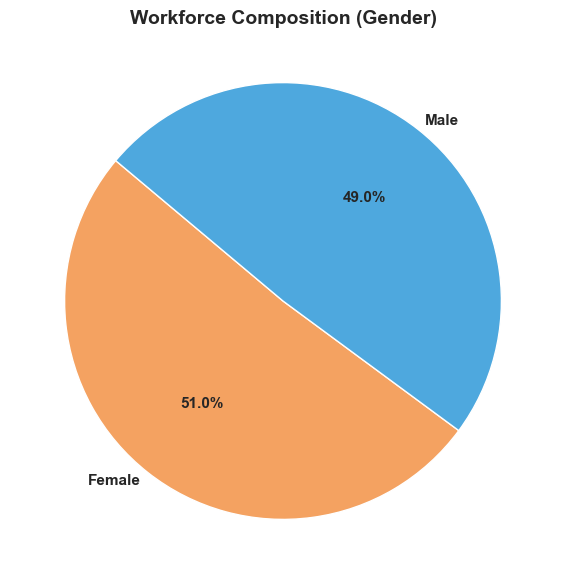

In [36]:
gender_counts = df["Gender"].value_counts()
plt.figure(figsize=(6, 6))

colors = ['#F4A261', '#4EA8DE'] 

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    radius=1.0,           
    labeldistance=1.05,   
    pctdistance=0.6,      
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title("Workforce Composition (Gender)", fontsize=14, fontweight="bold", pad=2) 
plt.tight_layout()
plt.show()


## Hiring Trends Over Time

In [37]:
df["Joining Date"] = pd.to_datetime(df["Joining Date"])
df["Joining Year"] = df["Joining Date"].dt.year

In [38]:
hiring_trends = df["Joining Year"].value_counts().sort_index().reset_index()
hiring_trends.columns = ["Year", "Employee Count"]

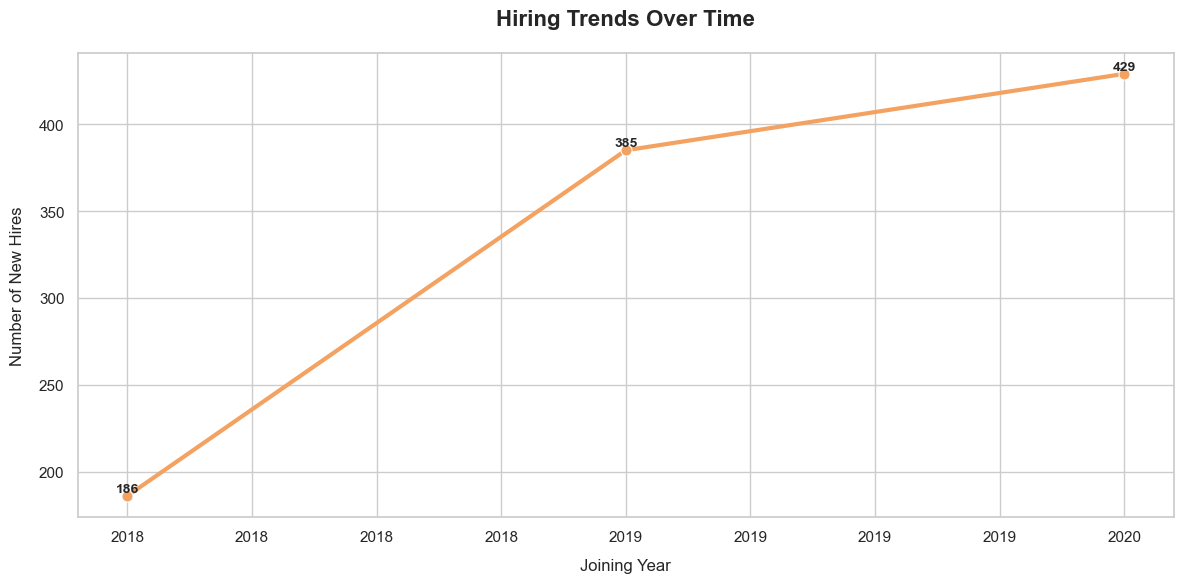

In [39]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    x="Year",
    y="Employee Count",
    data=hiring_trends,
    marker="o",  
    markersize=8,
    linewidth=3,
    color="#F4A261", 
)

for x, y in zip(hiring_trends["Year"], hiring_trends["Employee Count"]):
    plt.text(
        x,
        y + 0.5,
        str(int(y)),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
plt.title("Hiring Trends Over Time", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Joining Year", fontsize=12, labelpad=10)
plt.ylabel("Number of New Hires", fontsize=12, labelpad=10)
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter("%d"))
plt.tight_layout()
plt.show()

## Executive HR Analytics Dashboard

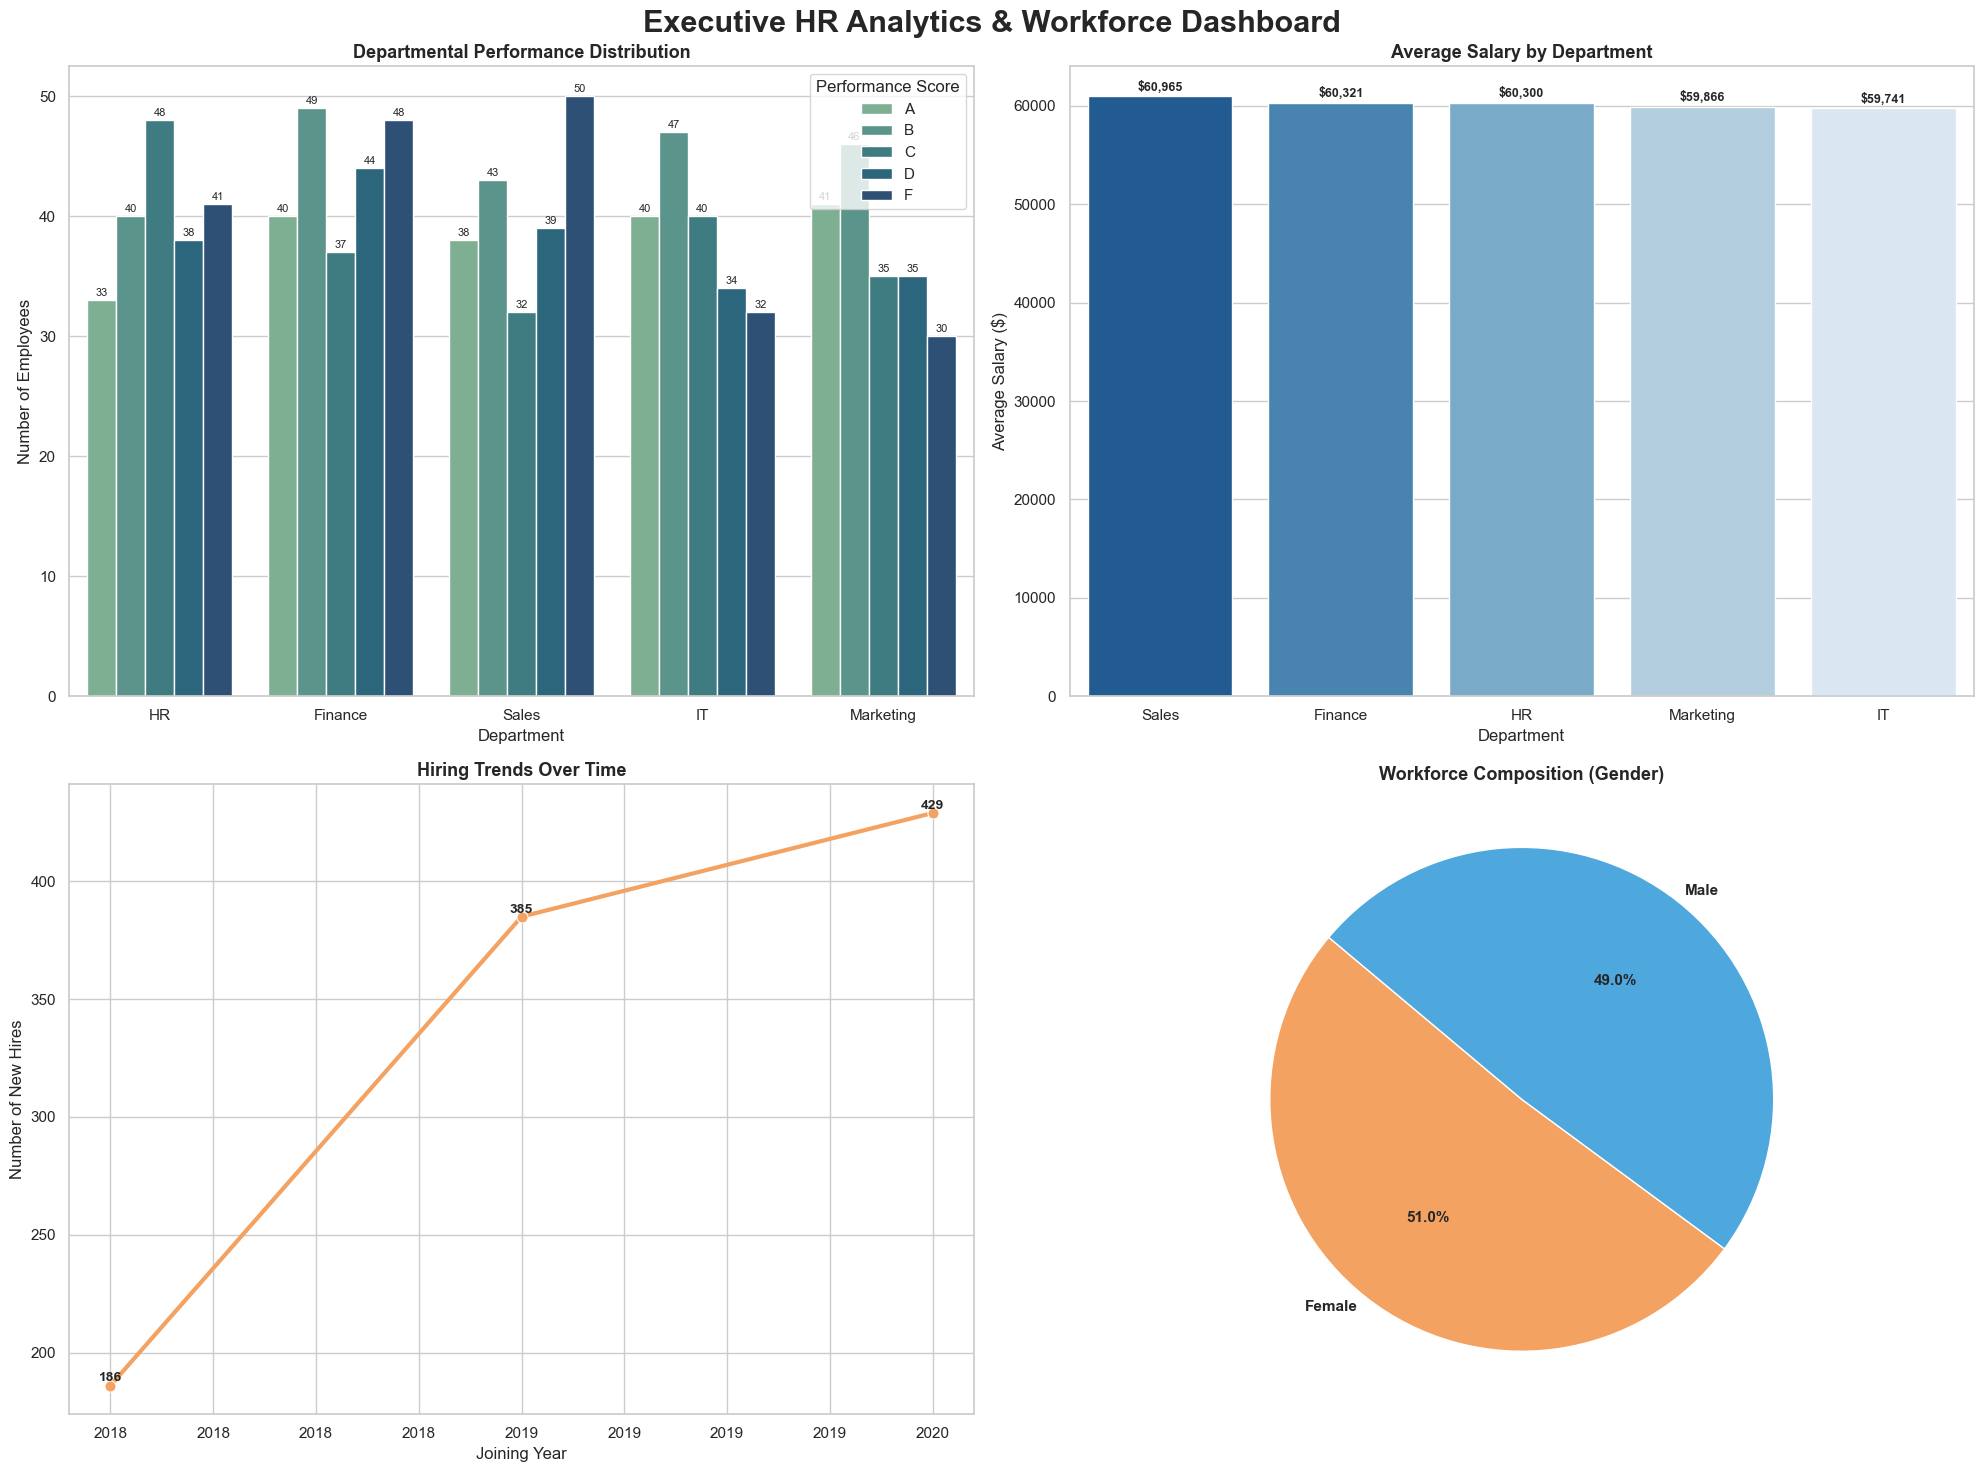

In [40]:
salary_df = df.groupby("Department")["Salary"].mean().reset_index()
salary_df = salary_df.sort_values(by="Salary", ascending=False)
gender_counts = df["Gender"].value_counts()
df["Joining Date"] = pd.to_datetime(df["Joining Date"])
df["Joining Year"] = df["Joining Date"].dt.year
hiring_trends = df["Joining Year"].value_counts().sort_index().reset_index()
hiring_trends.columns = ["Year", "Employee Count"]

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
sns.set_theme(style="whitegrid")

sns.countplot(
    x="Department", hue="Performance Score", data=df, 
    hue_order=['A', 'B', 'C', 'D', 'F'], palette="crest", ax=axes[0, 0]
)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%d', padding=2, fontsize=8)
axes[0, 0].set_title("Departmental Performance Distribution", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Department")
axes[0, 0].set_ylabel("Number of Employees")

sns.barplot(
    x="Department", y="Salary", data=salary_df, 
    hue="Department", legend=False, palette="Blues_r", ax=axes[0, 1]
)
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt='${:,.0f}', padding=2, fontsize=9, fontweight="bold")
axes[0, 1].set_title("Average Salary by Department", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Department")
axes[0, 1].set_ylabel("Average Salary ($)")

sns.lineplot(
    x="Year", y="Employee Count", data=hiring_trends,
    marker="o", markersize=8, linewidth=3, color="#F4A261", ax=axes[1, 0]
)
for x, y in zip(hiring_trends["Year"], hiring_trends["Employee Count"]):
    axes[1, 0].text(x, y + 0.5, str(int(y)), ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1, 0].set_title("Hiring Trends Over Time", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Joining Year")
axes[1, 0].set_ylabel("Number of New Hires")
axes[1, 0].xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

dashboard_colors = ['#F4A261', '#4EA8DE'] 
axes[1, 1].pie(
    gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
    startangle=140, colors=dashboard_colors, radius=1.0,
    labeldistance=1.05, pctdistance=0.6,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1, 1].set_title("Workforce Composition (Gender)", fontsize=13, fontweight="bold", pad=2)

plt.suptitle("Executive HR Analytics & Workforce Dashboard", fontsize=22, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()